In [173]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import gpytorch
import torch.nn as nn

In [174]:
df = pd.read_csv("/Users/taliacho/Downloads/Ranger/Bryan-Ranger/Unet/predicted_mask_areas.csv")
df.columns = ["Filename", "PixelArea", "FM", "FFM"]
df = df.dropna(subset=["PixelArea", "FM", "FFM"])
df = df[df["PixelArea"] > 0].reset_index(drop=True)
 
print(f"Loaded {len(df)} rows")
print(df.head())

Loaded 56 rows
              Filename  PixelArea      FM     FFM
0  20052118_AB4_R.jpeg       2700  0.3263  2.0420
1   21052318_A1_R.jpeg       2036  0.0911  2.4276
2  25061918_AB1_R.jpeg       1035  0.0590  1.5941
3  25061918_AB2_R.jpeg       3299  0.0590  1.5941
4  26061918_AB3_R.jpeg       2431  0.0808  1.6738


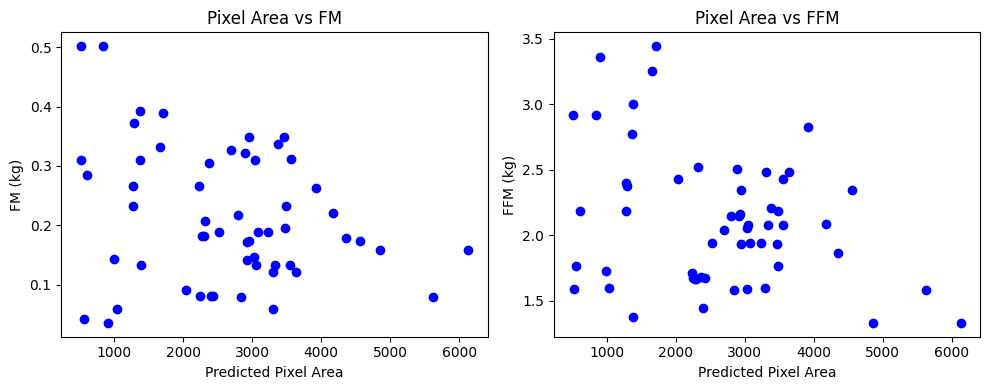

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df["PixelArea"], df["FM"], marker="o", color="b")
axes[0].set_title("Pixel Area vs FM")
axes[0].set_xlabel("Predicted Pixel Area")
axes[0].set_ylabel("FM (kg)")
 
axes[1].scatter(df["PixelArea"], df["FFM"], marker="o", color="b")
axes[1].set_title("Pixel Area vs FFM")
axes[1].set_xlabel("Predicted Pixel Area")
axes[1].set_ylabel("FFM (kg)")
 
plt.tight_layout()
plt.savefig("scatter_pixel_area.png", dpi=150)
plt.show()

In [176]:
matrix_3d = np.zeros((len(df), 2, 2))
for i, target_col in enumerate(["FM", "FFM"]):
    matrix_3d[:, 0, i] = df["PixelArea"].values
    matrix_3d[:, 1, i] = df[target_col].values
 
# ── 4. Train / test / valid split (mirrors original notebook) ─────────────────
def split_data(data, train_size=0.8, test_size=0.1, random_state=None):
    train, temp = train_test_split(data, train_size=train_size,
                                   random_state=random_state)
    test_ratio = test_size / (1.0 - train_size)
    test, valid = train_test_split(temp, test_size=test_ratio,
                                   random_state=random_state)
    return train, test, valid

In [177]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
 
    def forward(self, x):
        mean_x  = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [178]:
target_names = ["FM", "FFM"]
n_targets    = 2
training_iter = 50
 
rmse_vals = torch.zeros(n_targets, 1)
mse_vals  = torch.zeros(n_targets, 1)
mae_vals  = torch.zeros(n_targets, 1)
mape_vals = torch.zeros(n_targets, 1)
 
mse_loss_fn = nn.MSELoss()
mae_loss_fn = nn.L1Loss()
 
trained_models      = []
trained_likelihoods = []
test_sets           = []          # store for plotting later
 
for index in range(n_targets):
    print(f"\n{'='*60}")
    print(f"Training GP for target: {target_names[index]}")
    print(f"{'='*60}")
 
    data_tensor = torch.tensor(matrix_3d[:, :, index], dtype=torch.float32)
 
    train, test, valid = split_data(data_tensor, random_state=42)
 
    # Remove any NaN rows
    train = train[~torch.isnan(train).any(dim=1)]
    test  = test[~torch.isnan(test).any(dim=1)]
    valid = valid[~torch.isnan(valid).any(dim=1)]
 
    train_x, train_y = train[:, 0], train[:, 1]
    test_x,  test_y  = test[:, 0],  test[:, 1]
 
    # Normalise input for numerical stability
    x_mean, x_std = train_x.mean(), train_x.std()
    train_x_n = (train_x - x_mean) / x_std
    test_x_n  = (test_x  - x_mean) / x_std
 
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model      = ExactGPModel(train_x_n, train_y, likelihood)
 
    model.train()
    likelihood.train()
 
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll       = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
 
    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x_n)
        loss   = -mll(output, train_y)
        loss.backward()
        print(
            f"Iter {i+1:02d}/{training_iter} - Loss: {loss.item():.3f}   "
            f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():.3f}   "
            f"noise: {model.likelihood.noise.item():.3f}"
        )
        optimizer.step()
 
    print(f"done with index {index} ({target_names[index]})")
 
    # Evaluate
    model.eval()
    likelihood.eval()
 
    with torch.no_grad():
        preds  = model(test_x_n)
        f_mean = preds.mean
 
        mse_vals[index]  = mse_loss_fn(f_mean, test_y)
        rmse_vals[index] = torch.sqrt(mse_vals[index])
        mae_vals[index]  = mae_loss_fn(f_mean, test_y)
        mape_vals[index] = torch.mean(
            torch.abs((f_mean - test_y) / test_y)
        ) * 100
 
    trained_models.append(model)
    trained_likelihoods.append(likelihood)
    test_sets.append({
        "test_x": test_x, "test_x_n": test_x_n,
        "test_y": test_y, "x_mean": x_mean, "x_std": x_std
    })


Training GP for target: FM
Iter 01/50 - Loss: 0.864   lengthscale: 0.693   noise: 0.693
Iter 02/50 - Loss: 0.823   lengthscale: 0.744   noise: 0.644
Iter 03/50 - Loss: 0.781   lengthscale: 0.798   noise: 0.598
Iter 04/50 - Loss: 0.740   lengthscale: 0.854   noise: 0.554
Iter 05/50 - Loss: 0.699   lengthscale: 0.912   noise: 0.513
Iter 06/50 - Loss: 0.657   lengthscale: 0.972   noise: 0.474
Iter 07/50 - Loss: 0.615   lengthscale: 1.034   noise: 0.437
Iter 08/50 - Loss: 0.571   lengthscale: 1.097   noise: 0.402
Iter 09/50 - Loss: 0.527   lengthscale: 1.162   noise: 0.370
Iter 10/50 - Loss: 0.483   lengthscale: 1.228   noise: 0.340
Iter 11/50 - Loss: 0.439   lengthscale: 1.296   noise: 0.312
Iter 12/50 - Loss: 0.395   lengthscale: 1.363   noise: 0.285
Iter 13/50 - Loss: 0.350   lengthscale: 1.432   noise: 0.261
Iter 14/50 - Loss: 0.304   lengthscale: 1.500   noise: 0.238
Iter 15/50 - Loss: 0.259   lengthscale: 1.569   noise: 0.218
Iter 16/50 - Loss: 0.213   lengthscale: 1.638   noise: 0.

In [179]:
print("\n")
header = "{:<12} {:<10} {:<10} {:<10} {:<10}".format(
    "Target", "MAE", "MSE", "RMSE", "MAPE (%)"
)
print(header)
print("-" * len(header))
for index, name in enumerate(target_names):
    print("{:<12} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        name,
        mae_vals[index].item(),
        mse_vals[index].item(),
        rmse_vals[index].item(),
        mape_vals[index].item(),
    ))
 



Target       MAE        MSE        RMSE       MAPE (%)  
--------------------------------------------------------
FM           0.1353     0.0219     0.1478     195.5585  
FFM          0.3418     0.1653     0.4066     20.5540   


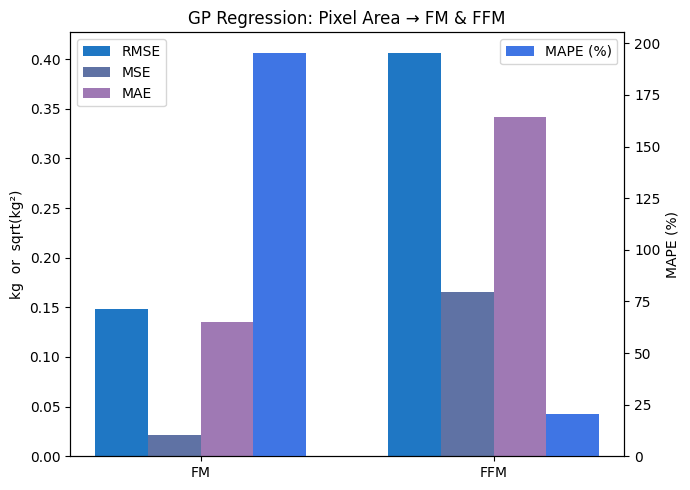

In [180]:
positions = torch.arange(n_targets)
width = 0.18
 
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.bar(positions - 1.5*width, rmse_vals.flatten().detach(), width,
        label="RMSE", color="#1f77c4")
ax1.bar(positions - 0.5*width, mse_vals.flatten().detach(),  width,
        label="MSE",  color="#5f72a4")
ax1.bar(positions + 0.5*width, mae_vals.flatten().detach(),  width,
        label="MAE",  color="#9f79b4")
 
ax2 = ax1.twinx()
ax2.bar(positions + 1.5*width, mape_vals.flatten().detach(), width,
        label="MAPE (%)", color="#3f75e4")
 
ax1.set_ylabel("kg  or  sqrt(kg²)")
ax2.set_ylabel("MAPE (%)")
ax1.set_title("GP Regression: Pixel Area → FM & FFM")
ax1.set_xticks(positions.numpy())
ax1.set_xticklabels(target_names)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("metrics_bar_chart.png", dpi=150)
plt.show()

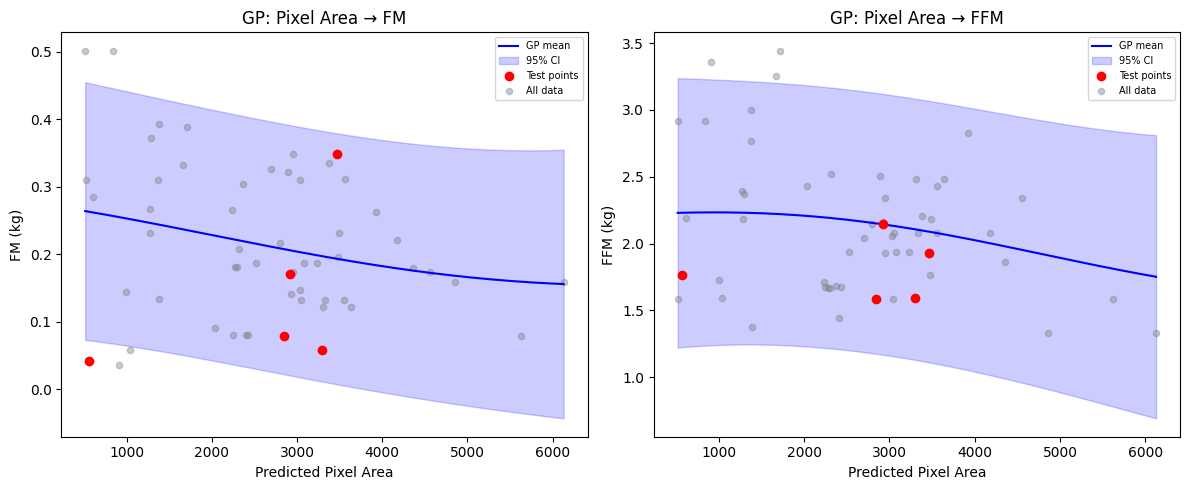


All plots saved.


In [181]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for index, (name, ax) in enumerate(zip(target_names, axes)):
    model      = trained_models[index]
    likelihood = trained_likelihoods[index]
    ts         = test_sets[index]
 
    # Dense grid in normalised space for smooth curve
    x_plot_raw = torch.linspace(
        df["PixelArea"].min(), df["PixelArea"].max(), 200
    )
    x_plot_n = (x_plot_raw - ts["x_mean"]) / ts["x_std"]
 
    model.eval(); likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        preds = likelihood(model(x_plot_n))
        lower, upper = preds.confidence_region()
 
    ax.plot(x_plot_raw.numpy(), preds.mean.numpy(),
            "b-", label="GP mean")
    ax.fill_between(x_plot_raw.numpy(),
                    lower.numpy(), upper.numpy(),
                    alpha=0.2, color="blue", label="95% CI")
    ax.scatter(ts["test_x"].numpy(), ts["test_y"].numpy(),
               color="red", zorder=5, label="Test points")
    ax.scatter(
        df["PixelArea"].values,
        df[name].values,
        color="gray", alpha=0.4, s=20, label="All data"
    )
    ax.set_title(f"GP: Pixel Area → {name}")
    ax.set_xlabel("Predicted Pixel Area")
    ax.set_ylabel(f"{name} (kg)")
    ax.legend(fontsize=7)
 
plt.tight_layout()
plt.savefig("gp_posterior_plots.png", dpi=150)
plt.show()
 
print("\nAll plots saved.")
 